In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Electric_Production.csv")
df


,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
...,...,...
392,9/1/2017,98.6154
393,10/1/2017,93.6137
394,11/1/2017,97.3359
395,12/1/2017,114.7212


In [2]:
# Convert date column
df['Date'] = pd.to_datetime(df['DATE'])

# Set date as index
df.set_index('Date', inplace=True)

# Display first rows
print(df.head())

                DATE  IPG2211A2N
Date                            
1985-01-01  1/1/1985     72.5052
1985-02-01  2/1/1985     70.6720
1985-03-01  3/1/1985     62.4502
1985-04-01  4/1/1985     57.4714
1985-05-01  5/1/1985     55.3151


In [3]:
print(df.describe())


       IPG2211A2N
count  397.000000
mean    88.847218
std     15.387834
min     55.315100
25%     77.105200
50%     89.779500
75%    100.524400
max    129.404800


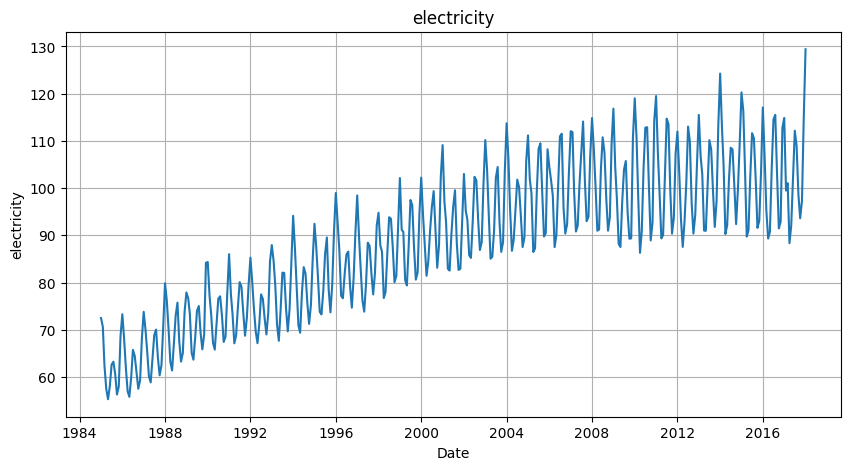

In [4]:
#Plotting temp
plt.figure(figsize=(10,5))
plt.plot(df.index, df['IPG2211A2N'])
plt.title("electricity")
plt.xlabel("Date")
plt.ylabel("electricity")
plt.grid(True)
plt.show()

Observation

The plot shows fluctuating temperature values over time, indicating daily variations in Delhi's climate.

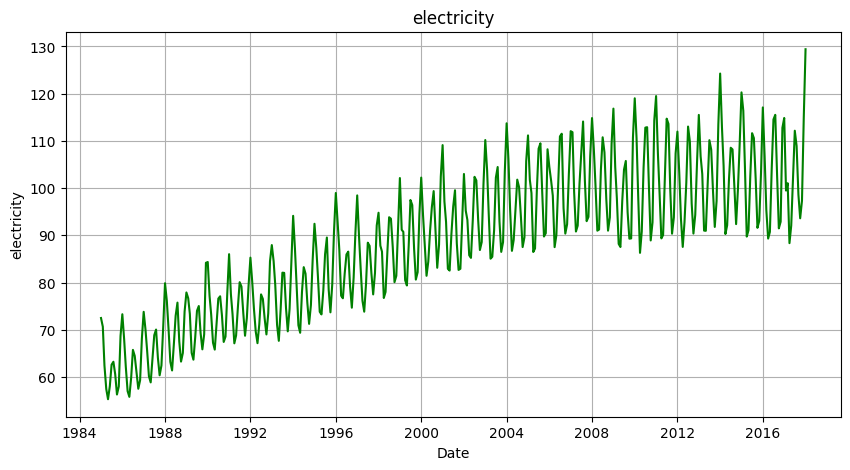

In [5]:
#Plotting number_sold (instead of humidity)
plt.figure(figsize=(10,5))
plt.plot(df.index, df['IPG2211A2N'], color='green')
plt.title("electricity")
plt.xlabel("Date")
plt.ylabel("electricity")
plt.grid(True)
plt.show()

Observation

Number of units sold shows significant variation, reflecting different sales conditions across days.

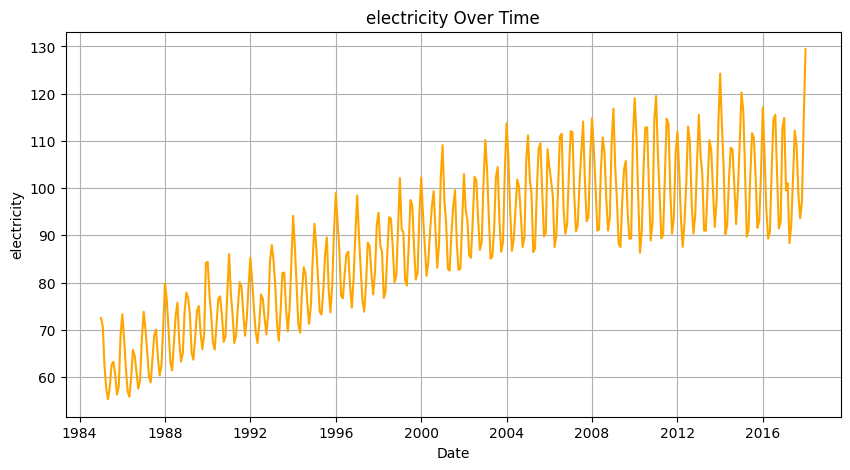

In [6]:
#plotting number_sold (instead of wind speed)
plt.figure(figsize=(10,5))
plt.plot(df.index, df['IPG2211A2N'], color='orange')
plt.title("electricity Over Time")
plt.xlabel("Date")
plt.ylabel("electricity")
plt.grid(True)
plt.show()

Observation

Number of units sold shows moderate fluctuations, indicating natural variation in sales conditions.

**The ADF test statistically checks whether a time series is stationary.**

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['IPG2211A2N'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.256990350047235
p-value: 0.1862146911658712


# Checking Seasonality (Time Series Decomposition)
**Seasonality refers to patterns that repeat over a fixed time period (daily, weekly, monthly, yearly)**

In [8]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [9]:
test_result=adfuller(df['IPG2211A2N'])

In [10]:
from statsmodels.tsa.stattools import adfuller

# H0: number_sold time series is non-stationary
# H1: number_sold time series is stationary

def adfuller_test(series):

    result = adfuller(series)

    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value, label in zip(result, labels):
        print(label + ' : ' + str(value))

    if result[1] <= 0.05:
        print("\nStrong evidence against the null hypothesis (H0).")
        print("Reject H0 → Number sold time series is stationary.")
    else:
        print("\nWeak evidence against the null hypothesis (H0).")
        print("Fail to reject H0 → Number sold time series is non-stationary.")

In [11]:
adfuller_test(df['IPG2211A2N'])

ADF Test Statistic : -2.256990350047235
p-value : 0.1862146911658712
#Lags Used : 15
Number of Observations Used : 381

Weak evidence against the null hypothesis (H0).
Fail to reject H0 → Number sold time series is non-stationary.


In [12]:
import matplotlib.pyplot as plt

def plot_rolling_stats(series):

    rolling_mean = series.rolling(window=12).mean()
    rolling_std = series.rolling(window=12).std()

    plt.figure(figsize=(10,5))

    plt.plot(series, color='blue', label='Original electricity')
    plt.plot(rolling_mean, color='red', label='Rolling Mean')
    plt.plot(rolling_std, color='black', label='Rolling Std')

    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation (Stationarity Check)')
    plt.xlabel('Date')
    plt.ylabel('electricity')

    plt.show()

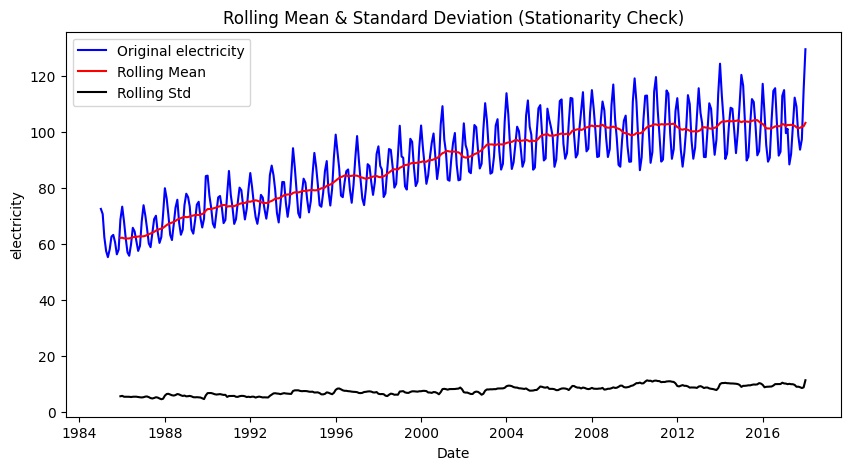

In [13]:
plot_rolling_stats(df['IPG2211A2N'])

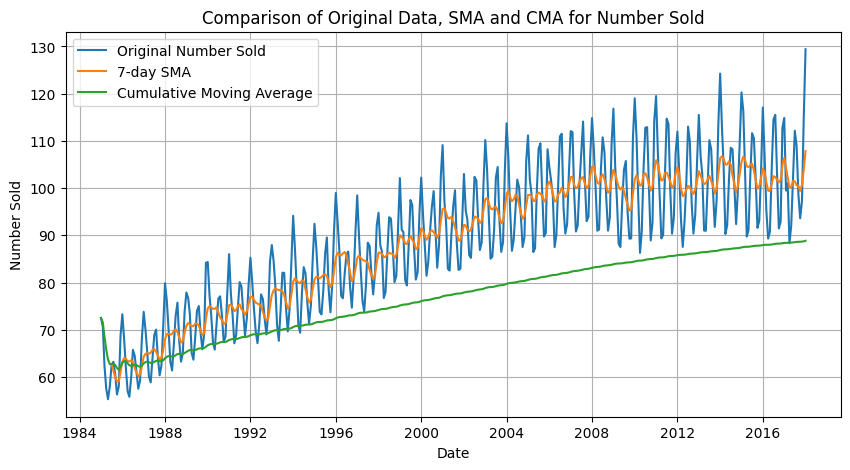

In [14]:
import matplotlib.pyplot as plt

# Calculate SMA and CMA for 'number_sold'
df['SMA_7'] = df['IPG2211A2N'].rolling(window=7).mean()
df['CMA'] = df['IPG2211A2N'].expanding().mean()

# Plot all on same graph
plt.figure(figsize=(10,5))

plt.plot(df['IPG2211A2N'], label='Original Number Sold')
plt.plot(df['SMA_7'], label='7-day SMA')
plt.plot(df['CMA'], label='Cumulative Moving Average')

plt.title("Comparison of Original Data, SMA and CMA for Number Sold")
plt.xlabel("Date")
plt.ylabel("Number Sold")

plt.legend()
plt.grid(True)

plt.show()